In [ ]:
import matplotlib.pyplot as plt
import random
import sklearn
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.metrics import log_loss
from sklearn.ensemble import RandomForestClassifier

In [14]:
def generate_column_partition(n, k, random_state, min_first=2):
    if k < 1:
        raise ValueError("Number of categories must be at least 1.")
    if n < min_first:
        raise ValueError("Total must be at least as large as the minimum first value.")

    rng = random.Random(random_state)

    min_first += 1
    remaining = n - min_first + 1

    # Generate k-1 non-negative integers that sum to `remaining`
    # This is done by generating (k-2) cut points between 0 and remaining,
    # and sorting them to form the segments
    cuts = sorted(rng.sample(range(remaining + k - 1), k - 1))
    partition = [cuts[0]]
    for i in range(1, len(cuts)):
        partition.append(cuts[i] - cuts[i - 1])
    partition.append(remaining + k - 1 - cuts[-1])

    # Subtract 1 from each (stars and bars method)
    partition = [x - 1 for x in partition]

    # Prepend the fixed minimum for the first category
    partition[0] += min_first

    return partition

In [15]:
def generate_dataset(n_samples=1000, n_features=20, random_state=213):

    partition = generate_column_partition(n_features, 5, random_state=random_state)

    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=partition[0],
        n_redundant=partition[1],
        n_repeated=partition[2] + partition[3],
        n_clusters_per_class=2,
        class_sep=1.0,
        random_state=random_state,
        shuffle=False,
    )

    correlated_index_start = partition[0] + partition[1]
    noise_index_start = correlated_index_start + partition[2]

    for i in range(partition[2]):
        index = correlated_index_start + i
        X[:, index] += np.random.normal(loc=0.0, scale=0.1, size=n_samples)

    for i in range(partition[3]):
        index = noise_index_start + i
        X[:, index] += np.random.uniform(low=-1.0, high=1.0, size=n_samples)

    labels = ["informative", "redundant", "correlated", "noise", "irrelevant"]
    idx = np.cumsum([0] + partition)
    feature_types = {
        "informative": list(range(idx[0], idx[1])),
        "redundant": list(range(idx[1], idx[2])),
        "correlated": list(range(idx[2], idx[3])),
        "noise": list(range(idx[3], idx[4])),
        "pure_noise": list(range(idx[4], idx[5])),
    }

    print(partition)
    print()

    for key, val in feature_types.items():
        print(key, val)
    return X, y, feature_types

In [19]:
X, y, _ = generate_dataset()

[6, 2, 1, 3, 8]

informative [0, 1, 2, 3, 4, 5]
redundant [6, 7]
correlated [8]
noise [9, 10, 11]
pure_noise [12, 13, 14, 15, 16, 17, 18, 19]


In [30]:
X, y, feature_types = generate_dataset(n_samples=500, n_features=20, random_state=420)
num_of_informative_features = len(feature_types["informative"])

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Store results
selected_features = {}

# --- 1. LASSO ---
lasso = LassoCV(cv=5, random_state=42).fit(X_train, y_train)
lasso_selected = np.where(lasso.coef_ != 0)[0].tolist()
selected_features["lasso"] = lasso_selected

# --- 2. Mutual Information ---
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_selected = np.argsort(mi_scores)[-num_of_informative_features:].tolist()
selected_features["mutual_info"] = mi_selected

# --- 3. Correlation ---
correlations = []
for i in range(X_train.shape[1]):
    corr = np.corrcoef(X_train[:, i], y_train)[0, 1]
    correlations.append((i, abs(corr)))

correlated = [
    i
    for i, _ in sorted(correlations, key=lambda x: -x[1])[:num_of_informative_features]
]
selected_features["correlation"] = correlated


# --- 4. BIC Wrapper (Logistic Regression with feature subsets) ---
def bic_score(model, X, y):
    """Calculate BIC for a fitted logistic regression model"""
    n = len(y)
    k = X.shape[1]
    prob = model.predict_proba(X)[:, 1]
    ll = -log_loss(y, prob, normalize=False)  # log-likelihood
    bic = k * np.log(n) - 2 * ll
    return bic


def bic_forward_selection(X, y, max_features=None):
    selected = []
    remaining = list(range(X.shape[1]))
    best_bic = np.inf

    while remaining:
        scores = []
        for feat in remaining:
            candidate = selected + [feat]
            model = LogisticRegression(solver="liblinear").fit(X[:, candidate], y)
            bic = bic_score(model, X[:, candidate], y)
            scores.append((bic, feat))

        # Find the best new feature to add
        scores.sort()
        best_new_bic, best_feat = scores[0]

        # Stop if BIC does not improve
        if best_new_bic < best_bic:
            best_bic = best_new_bic
            selected.append(best_feat)
            remaining.remove(best_feat)
            if max_features and len(selected) >= max_features:
                break
        else:
            break

    return selected


bic_selected = bic_forward_selection(X_train, y_train)
selected_features["bic"] = bic_selected

# --- 5. Random Forest Feature Importance ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
rf_selected = np.argsort(importances)[-num_of_informative_features:].tolist()
selected_features["random_forest"] = rf_selected

# --- Print results ---
for method, features in selected_features.items():
    print(f"{method}: selected feature indices: {features}")

[2, 7, 2, 9, 0]

informative [0, 1]
redundant [2, 3, 4, 5, 6, 7, 8]
correlated [9, 10]
noise [11, 12, 13, 14, 15, 16, 17, 18, 19]
pure_noise []
lasso: selected feature indices: [1, 6, 13, 15, 16]
mutual_info: selected feature indices: [1, 2]
correlation: selected feature indices: [2, 1]
bic: selected feature indices: [2]
random_forest: selected feature indices: [1, 2]


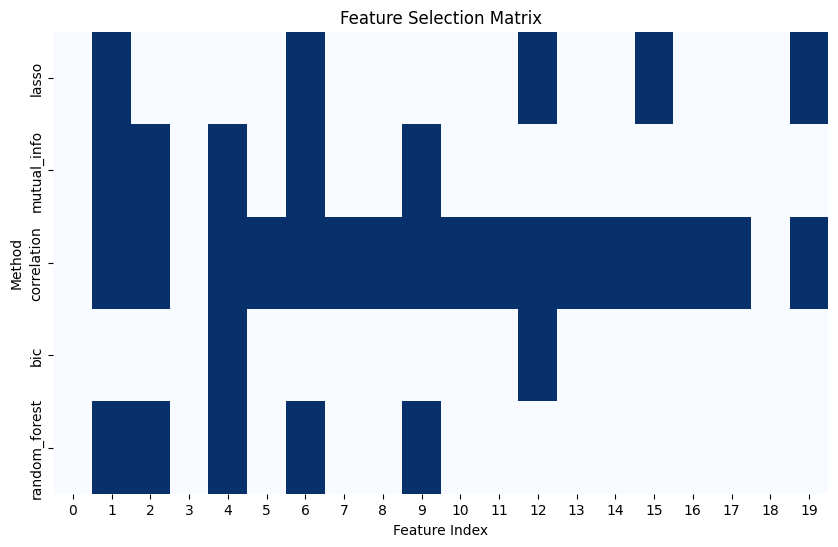

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create binary matrix of selections
feature_matrix = pd.DataFrame(
    0, index=range(X.shape[1]), columns=selected_features.keys()
)
for method, features in selected_features.items():
    feature_matrix.loc[features, method] = 1

plt.figure(figsize=(10, 6))
sns.heatmap(feature_matrix.T, cmap="Blues", cbar=False)
plt.title("Feature Selection Matrix")
plt.xlabel("Feature Index")
plt.ylabel("Method")
plt.show()